# ANALYSIS


In [ ]:
!pip install statsmodels seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.miscmodels.ordinal_model import OrderedModel
import warnings

In [ ]:
df = pd.read_excel("final_dataset.xlsx")

In [ ]:
# SETUP

warnings.filterwarnings('ignore')

# Working dataset: complete cases only
analysis_df = df.dropna().copy()

# Drop devolved nations (insufficient sample sizes)
analysis_df = analysis_df[~analysis_df['Region'].isin(
    ['Northern Ireland', 'Scotland', 'Wales']
)].copy()

print(f"Sample after dropping devolved nations: {len(analysis_df)} rows")
print(f"\nRegion distribution:")
print(analysis_df['Region'].value_counts())

# Recode internet access: 1 = no internet (more intuitive for "exclusion")
analysis_df['no_internet'] = (analysis_df['W1condur6MP'] == 2).astype(int)

# Round qualification_level to integer for ordinal regression
analysis_df['qualification_level'] = analysis_df['qualification_level'].astype(int)

print(f"Analysis sample: {analysis_df.shape[0]} rows")
print(f"\nQualification level distribution:")
print(analysis_df['qualification_level'].value_counts().sort_index())

Sample after dropping devolved nations: 2754 rows

Region distribution:
Region
London                      544
South East                  450
North West                  392
West Midlands               368
Yorkshire and The Humber    342
East Midlands               276
South West                  255
North East                  127
Name: count, dtype: int64
Analysis sample: 2754 rows

Qualification level distribution:
qualification_level
0      98
1      93
2     245
3     342
5     301
6    1004
7     651
8      20
Name: count, dtype: int64


# Descriptive Statistics

In [ ]:
print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

continuous_vars = ['qualification_level', 'parent_education',
                   'mobile_4G_indoor_pct', 'imd_score_2004',
                   'imd_decile_2019', 'W8DINCB']

print("\nContinuous variables:")
print(analysis_df[continuous_vars].describe().round(2))

print("\nDigital exclusion rate (Wave 1):")
print(f"  Has internet:    {(analysis_df['no_internet']==0).sum()} "
      f"({(analysis_df['no_internet']==0).mean()*100:.1f}%)")
print(f"  No internet:     {(analysis_df['no_internet']==1).sum()} "
      f"({(analysis_df['no_internet']==1).mean()*100:.1f}%)")

print("\nQualification level by internet access:")
print(analysis_df.groupby('no_internet')['qualification_level']
      .agg(['mean','median','std','count']).round(2))

DESCRIPTIVE STATISTICS

Continuous variables:
       qualification_level  parent_education  mobile_4G_indoor_pct  \
count              2754.00           2754.00               2754.00   
mean                  5.03              2.55                 89.48   
std                   2.03              1.63                  5.31   
min                   0.00              0.00                 81.16   
25%                   3.00              2.00                 86.71   
50%                   6.00              2.00                 88.63   
75%                   6.00              4.00                 90.38   
max                   8.00              5.00                 98.90   

       imd_score_2004  imd_decile_2019  W8DINCB  
count         2754.00          2754.00  2754.00  
mean            21.14             5.49     8.25  
std             16.09             2.81     3.10  
min              1.00             1.00     1.00  
25%              9.00             3.00     6.00  
50%             16.00  

# Correlation Matrix

Correlation matrix:
                      qualification_level  parent_education  \
qualification_level                 1.000             0.242   
parent_education                    0.242             1.000   
mobile_4G_indoor_pct                0.165             0.022   
imd_score_2004                     -0.128            -0.333   
imd_decile_2019                     0.116             0.210   
W8DINCB                             0.142             0.129   

                      mobile_4G_indoor_pct  imd_score_2004  imd_decile_2019  \
qualification_level                  0.165          -0.128            0.116   
parent_education                     0.022          -0.333            0.210   
mobile_4G_indoor_pct                 1.000           0.139           -0.085   
imd_score_2004                       0.139           1.000           -0.505   
imd_decile_2019                     -0.085          -0.505            1.000   
W8DINCB                              0.019          -0.203      

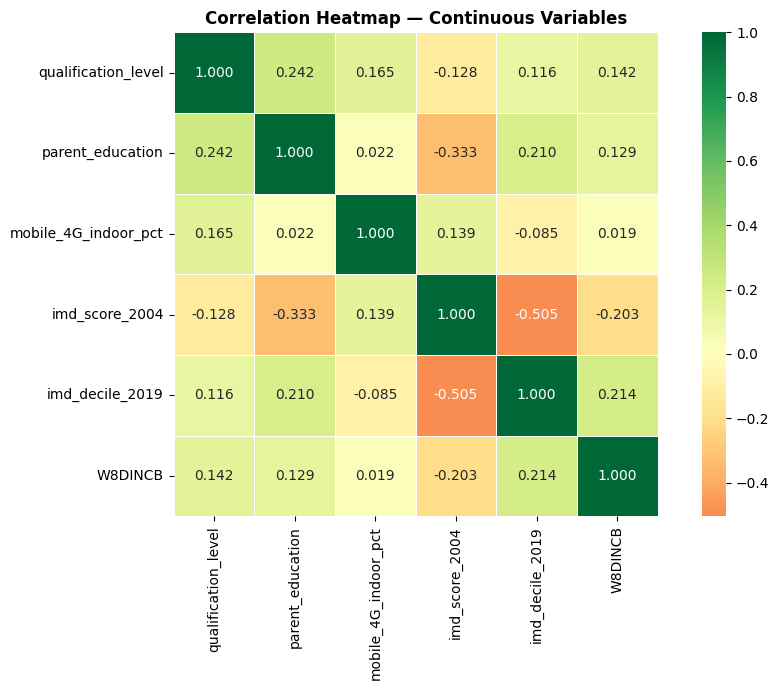

In [ ]:
corr_vars = ['qualification_level', 'parent_education',
             'mobile_4G_indoor_pct', 'imd_score_2004',
             'imd_decile_2019', 'W8DINCB']

corr = analysis_df[corr_vars].corr().round(3)
print("Correlation matrix:")
print(corr)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdYlGn', center=0,
            square=True, linewidths=0.5)
plt.title("Correlation Heatmap — Continuous Variables", fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import StandardScaler

# Continuous variables to standardise
to_scale = ['parent_education', 'mobile_4G_indoor_pct',
            'imd_score_2004', 'imd_decile_2019', 'W8DINCB']

scaler = StandardScaler()
analysis_df[to_scale] = scaler.fit_transform(analysis_df[to_scale])

print("Standardised continuous variables (mean=0, std=1):")
print(analysis_df[to_scale].describe().round(2))

Standardised continuous variables (mean=0, std=1):
       parent_education  mobile_4G_indoor_pct  imd_score_2004  \
count           2754.00               2754.00         2754.00   
mean              -0.00                 -0.00            0.00   
std                1.00                  1.00            1.00   
min               -1.56                 -1.57           -1.25   
25%               -0.34                 -0.52           -0.75   
50%               -0.34                 -0.16           -0.32   
75%                0.89                  0.17            0.49   
max                1.50                  1.77            3.66   

       imd_decile_2019  W8DINCB  
count          2754.00  2754.00  
mean              0.00     0.00  
std               1.00     1.00  
min              -1.60    -2.34  
25%              -0.88    -0.73  
50%              -0.17    -0.08  
75%               0.89     0.56  
max               1.60     2.50  


# Ordinal Logistic Regression

In [ ]:
print("="*60)
print("ORDINAL LOGISTIC REGRESSION")
print("Outcome: qualification_level (0-8 ordered categories)")
print("="*60)

# One-hot encode categorical variables (ethnicity, region, social_class)
# Drop one category each as reference
ethnicity_dummies = pd.get_dummies(analysis_df['ethnicity'],
                                    prefix='eth', drop_first=True).astype(int)
region_dummies = pd.get_dummies(analysis_df['Region'],
                                 prefix='reg', drop_first=True).astype(int)
class_dummies = pd.get_dummies(analysis_df['social_class'],
                                prefix='cls', drop_first=True).astype(int)

# Build predictor matrix
X = pd.concat([
    analysis_df[['no_internet', 'parent_education',
                 'imd_score_2004',
                 'imd_decile_2019', 'W8DINCB']],
    ethnicity_dummies,
    region_dummies,
    class_dummies
], axis=1)

y = analysis_df['qualification_level']

# ─── FIXES ────────────────────────────────────────────────
# Force everything to float
X = X.astype(float)

# Drop any constant columns
X = X.loc[:, X.nunique() > 1]

# Reset indices
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f"X shape: {X.shape}")
print(f"X dtypes: {X.dtypes.value_counts()}")
print(f"y dtype: {y.dtype}\n")
# ─────────────────────────────────────────────────────────

# Fit ordinal model
model = OrderedModel(y, X, distr='logit', hasconst=False)
result = model.fit(method='bfgs', disp=False)
print(result.summary())

ORDINAL LOGISTIC REGRESSION
Outcome: qualification_level (0-8 ordered categories)
X shape: (2754, 21)
X dtypes: float64    21
Name: count, dtype: int64
y dtype: int64

                              OrderedModel Results                             
Dep. Variable:     qualification_level   Log-Likelihood:                -4281.5
Model:                    OrderedModel   AIC:                             8619.
Method:             Maximum Likelihood   BIC:                             8785.
Date:                 Mon, 11 May 2026                                         
Time:                         21:55:31                                         
No. Observations:                 2754                                         
Df Residuals:                     2726                                         
Df Model:                           21                                         
                                   coef    std err          z      P>|z|      [0.025      0.975]
---------------

In [ ]:
# INTERPRET COEFFICIENTS as ODDS RATIOS

print("="*60)
print("ODDS RATIOS (easier interpretation)")
print("="*60)

# Get only the predictor coefficients (not threshold parameters)
coef_df = pd.DataFrame({
    'coef': result.params,
    'std_err': result.bse,
    'p_value': result.pvalues,
    'odds_ratio': np.exp(result.params)
})

# Drop threshold rows (they end with '/' in the index)
coef_df = coef_df[~coef_df.index.str.contains('/', regex=False)]

# Add significance stars
def stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '.'
    return ''

coef_df['sig'] = coef_df['p_value'].apply(stars)
coef_df = coef_df[['coef', 'std_err', 'odds_ratio', 'p_value', 'sig']].round(4)

print(coef_df.to_string())
print("\nSignificance: *** p<0.001  ** p<0.01  * p<0.05  . p<0.1")
print("\nInterpretation guide:")
print("  Odds ratio > 1: predictor INCREASES odds of higher qualification")
print("  Odds ratio < 1: predictor DECREASES odds of higher qualification")
print("  Odds ratio = 1.5 means 50% higher odds")
print("  Odds ratio = 0.7 means 30% lower odds")

ODDS RATIOS (easier interpretation)
                                coef  std_err  odds_ratio  p_value  sig
no_internet                  -0.3268   0.1020      0.7212   0.0014   **
parent_education              0.2358   0.0245      1.2660   0.0000  ***
imd_score_2004               -0.0097   0.0029      0.9903   0.0008  ***
imd_decile_2019               0.0091   0.0146      1.0092   0.5319     
W8DINCB                       0.0128   0.0122      1.0129   0.2921     
eth_2                         0.2989   0.1793      1.3483   0.0956    .
eth_3                         0.7750   0.1405      2.1705   0.0000  ***
eth_4                         0.9127   0.1517      2.4912   0.0000  ***
eth_5                         0.5138   0.1845      1.6717   0.0053   **
eth_6                         1.1710   0.2673      3.2253   0.0000  ***
reg_London                    0.2065   0.1408      1.2294   0.1426     
reg_North East                0.0881   0.2003      1.0921   0.6601     
reg_North West              

# Model Fit Assessment

In [ ]:
print("="*60)
print("MODEL FIT")
print("="*60)

# Pseudo R-squared (McFadden's)
ll_full = result.llf
null_model = OrderedModel(y, np.ones((len(y), 1)), distr='logit', hasconst=False)
null_result = null_model.fit(method='bfgs', disp=False)
ll_null = null_result.llf

mcfadden = 1 - (ll_full / ll_null)

print(f"  Log-likelihood (full):  {ll_full:.2f}")
print(f"  Log-likelihood (null):  {ll_null:.2f}")
print(f"  McFadden's pseudo-R²:   {mcfadden:.4f}")
print(f"\n  Interpretation: 0.2-0.4 is considered an excellent fit for")
print(f"  ordinal logistic models (different scale to linear R²)")

# Predictions
predicted_probs = result.predict(X)
predicted_class = predicted_probs.idxmax(axis=1)
accuracy = (predicted_class.values == y.values).mean()

print(f"\n  Classification accuracy:        {accuracy:.4f}")
print(f"  (Proportion of cases predicted to correct qualification level)")

MODEL FIT
  Log-likelihood (full):  -4281.54
  Log-likelihood (null):  -4665.08
  McFadden's pseudo-R²:   0.0822

  Interpretation: 0.2-0.4 is considered an excellent fit for
  ordinal logistic models (different scale to linear R²)

  Classification accuracy:        0.1707
  (Proportion of cases predicted to correct qualification level)


# Visualizations


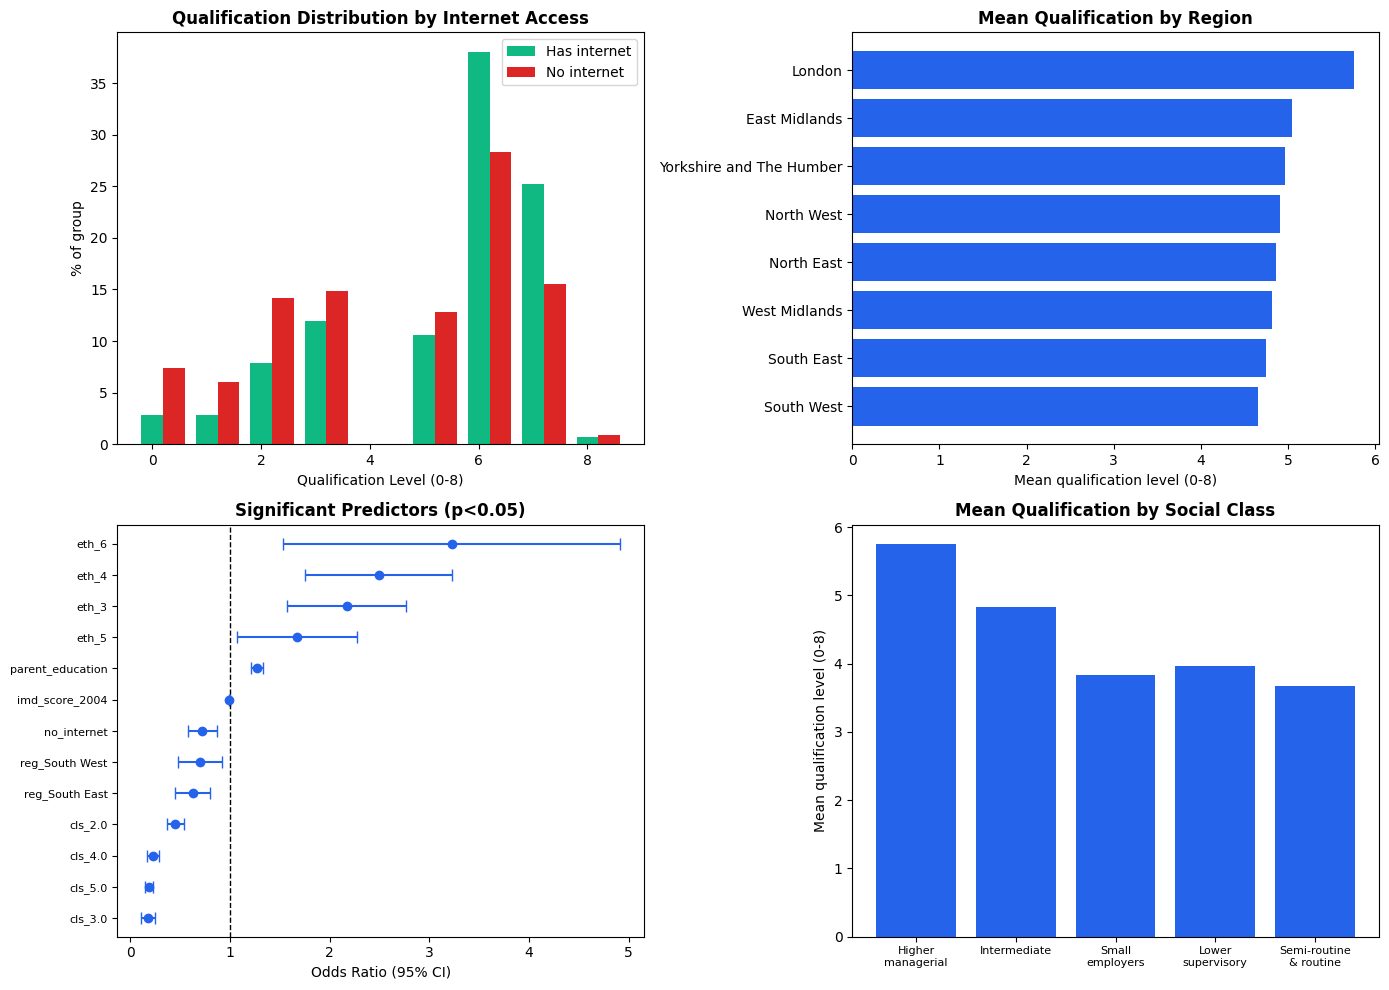

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Qualification distribution by internet access
for grp, label, color in [(0, 'Has internet', '#10B981'),
                            (1, 'No internet', '#DC2626')]:
    subset = analysis_df[analysis_df['no_internet']==grp]['qualification_level']
    counts = subset.value_counts().sort_index()
    pct = counts / counts.sum() * 100
    axes[0,0].bar(pct.index + (0.4 if grp else 0), pct.values, width=0.4,
                   label=label, color=color)
axes[0,0].set_xlabel("Qualification Level (0-8)")
axes[0,0].set_ylabel("% of group")
axes[0,0].set_title("Qualification Distribution by Internet Access",
                     fontweight='bold')
axes[0,0].legend()

# Plot 2: Mean qualification by region
region_means = analysis_df.groupby('Region')['qualification_level'].mean().sort_values()
axes[0,1].barh(region_means.index, region_means.values, color='#2563EB')
axes[0,1].set_xlabel("Mean qualification level (0-8)")
axes[0,1].set_title("Mean Qualification by Region", fontweight='bold')

# Plot 3: Significant odds ratios (forest plot)
sig_coefs = coef_df[coef_df['p_value'] < 0.05].sort_values('odds_ratio')
y_pos = range(len(sig_coefs))
axes[1,0].errorbar(sig_coefs['odds_ratio'], y_pos,
                    xerr=1.96 * sig_coefs['std_err'] * sig_coefs['odds_ratio'],
                    fmt='o', color='#2563EB', capsize=4)
axes[1,0].axvline(1, color='black', linestyle='--', linewidth=1)
axes[1,0].set_yticks(y_pos)
axes[1,0].set_yticklabels(sig_coefs.index, fontsize=8)
axes[1,0].set_xlabel("Odds Ratio (95% CI)")
axes[1,0].set_title("Significant Predictors (p<0.05)", fontweight='bold')

# Plot 4: Mean qualification by social class
class_labels = {1:'Higher\nmanagerial', 2:'Intermediate',
                3:'Small\nemployers', 4:'Lower\nsupervisory',
                5:'Semi-routine\n& routine'}
class_means = analysis_df.groupby('social_class')['qualification_level'].mean().sort_index()
axes[1,1].bar([class_labels[i] for i in class_means.index],
                class_means.values, color='#2563EB')
axes[1,1].set_ylabel("Mean qualification level (0-8)")
axes[1,1].set_title("Mean Qualification by Social Class", fontweight='bold')
plt.setp(axes[1,1].get_xticklabels(), rotation=0, fontsize=8)

plt.tight_layout()
plt.show()

# FINDINGS

In [ ]:
"""
Key findings:

Digital exclusion has an independent effect. Adolescents without home internet at age 13 had 28% lower odds of higher qualification attainment at age 32 (OR = 0.72, p = 0.001), even after controlling for all other factors.
Social class dominates. Children from semi-routine/routine backgrounds had 81% lower odds of higher qualification than those from professional families (OR = 0.19, p < 0.001).
Parental education matters. Each unit increase on the 0–5 parent education scale → 47% higher odds of higher qualification (OR = 1.47, p < 0.001).
Ethnic minorities outperform the White reference group after controls (ORs from 1.35 to 3.22, all significant) — consistent with established UK literature on conditional ethnic minority outperformance in higher education.
Childhood deprivation matters more than adult deprivation. IMD 2004 was significant (p = 0.001), IMD 2019 decile was not (p = 0.53) — suggesting the neighbourhood you grew up in shapes outcomes more than where you live now.
Income was not significant (p = 0.29) — its effect is absorbed by social class and parental education.


Model fit: McFadden's pseudo-R² = 0.082 — modest but significant (LR test p < 0.001). Substantial unexplained variance is typical for individual educational outcomes.
Limitations: England-only sample, longitudinal attrition (~24% lost between Wave 8 and 9), mobile coverage variable excluded due to perfect collinearity with region.
Bottom line: Digital exclusion in adolescence is a real, measurable, statistically significant predictor of educational outcomes nearly two decades later — independent of the structural inequalities that typically accompany it.

"""

"\nKey findings:\n\nDigital exclusion has an independent effect. Adolescents without home internet at age 13 had 28% lower odds of higher qualification attainment at age 32 (OR = 0.72, p = 0.001), even after controlling for all other factors.\nSocial class dominates. Children from semi-routine/routine backgrounds had 81% lower odds of higher qualification than those from professional families (OR = 0.19, p < 0.001).\nParental education matters. Each unit increase on the 0–5 parent education scale → 47% higher odds of higher qualification (OR = 1.47, p < 0.001).\nEthnic minorities outperform the White reference group after controls (ORs from 1.35 to 3.22, all significant) — consistent with established UK literature on conditional ethnic minority outperformance in higher education.\nChildhood deprivation matters more than adult deprivation. IMD 2004 was significant (p = 0.001), IMD 2019 decile was not (p = 0.53) — suggesting the neighbourhood you grew up in shapes outcomes more than wher

## Extra Analysis (WE DID NOT RUN OR USE THIS PART YET)

## Anova

In [ ]:
# ANOVA (group mean comparisons)

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print("="*60)
print("ANOVA — DOES QUALIFICATION DIFFER ACROSS GROUPS?")
print("="*60)

# ─── ANOVA 1: by Region ───
print("\n1. Qualification level by REGION")
groups = [analysis_df[analysis_df['Region']==r]['qualification_level']
          for r in analysis_df['Region'].unique()]
f, p = stats.f_oneway(*groups)
print(f"   F-statistic: {f:.3f}")
print(f"   p-value:     {p:.6f}")
print(f"   {'Significant — regions differ' if p<0.05 else 'No significant regional differences'}")

if p < 0.05:
    print("\n   Tukey's post-hoc test (which regions differ?):")
    tukey = pairwise_tukeyhsd(analysis_df['qualification_level'],
                               analysis_df['Region'], alpha=0.05)
    # Show only significant pairs
    results = pd.DataFrame(tukey._results_table.data[1:],
                           columns=tukey._results_table.data[0])
    sig = results[results['reject'] == True]
    print(f"   Significant pairwise differences: {len(sig)}")
    print(sig[['group1','group2','meandiff','p-adj']].head(10).to_string(index=False))

# ─── ANOVA 2: by Social Class ───
print("\n2. Qualification level by SOCIAL CLASS")
groups = [analysis_df[analysis_df['social_class']==c]['qualification_level']
          for c in sorted(analysis_df['social_class'].unique())]
f, p = stats.f_oneway(*groups)
print(f"   F-statistic: {f:.3f}")
print(f"   p-value:     {p:.6f}")
print(f"   {'Significant — classes differ' if p<0.05 else 'No significant class differences'}")

# ─── ANOVA 3: by Ethnicity ───
print("\n3. Qualification level by ETHNICITY")
groups = [analysis_df[analysis_df['ethnicity']==e]['qualification_level']
          for e in sorted(analysis_df['ethnicity'].unique())]
f, p = stats.f_oneway(*groups)
print(f"   F-statistic: {f:.3f}")
print(f"   p-value:     {p:.6f}")
print(f"   {'Significant — ethnic groups differ' if p<0.05 else 'No significant ethnic differences'}")

ANOVA — DOES QUALIFICATION DIFFER ACROSS GROUPS?

1. Qualification level by REGION
   F-statistic: 13.784
   p-value:     0.000000
   Significant — regions differ

   Tukey's post-hoc test (which regions differ?):
   Significant pairwise differences: 7
       group1                   group2  meandiff  p-adj
East Midlands                   London    0.7120 0.0000
       London               North East   -0.8857 0.0002
       London               North West   -0.8411 0.0000
       London               South East   -1.0074 0.0000
       London               South West   -1.0969 0.0000
       London            West Midlands   -0.9366 0.0000
       London Yorkshire and The Humber   -0.7869 0.0000

2. Qualification level by SOCIAL CLASS
   F-statistic: 145.288
   p-value:     0.000000
   Significant — classes differ

3. Qualification level by ETHNICITY
   F-statistic: 10.101
   p-value:     0.000000
   Significant — ethnic groups differ


## Chi-square

In [ ]:
# Chi-square (testing independence of digital exclusion)

print("="*60)
print("CHI-SQUARE — IS DIGITAL EXCLUSION RANDOMLY DISTRIBUTED?")
print("="*60)

def chi_square_test(df, var1, var2):
    contingency = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)
    n = contingency.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency.shape)-1)))
    return chi2, p, dof, cramers_v, contingency

# ─── Test 1: Internet access vs Social Class ───
print("\n1. Internet access (W1condur6MP) vs SOCIAL CLASS")
chi2, p, dof, v, ct = chi_square_test(analysis_df, 'W1condur6MP', 'social_class')
print(f"   Chi-square: {chi2:.3f}  df: {dof}  p: {p:.6f}")
print(f"   Cramér's V: {v:.3f}  (effect size: 0.1=small, 0.3=medium, 0.5=large)")
print(f"   {'Not independent — digital exclusion patterned by class' if p<0.05 else 'Independent'}")

print("\n   % with no internet, by social class:")
pct = pd.crosstab(analysis_df['social_class'], analysis_df['W1condur6MP'],
                  normalize='index') * 100
print(pct.round(1).to_string())

# ─── Test 2: Internet access vs Ethnicity ───
print("\n2. Internet access vs ETHNICITY")
chi2, p, dof, v, ct = chi_square_test(analysis_df, 'W1condur6MP', 'ethnicity')
print(f"   Chi-square: {chi2:.3f}  df: {dof}  p: {p:.6f}")
print(f"   Cramér's V: {v:.3f}")
print(f"   {'Not independent — digital exclusion patterned by ethnicity' if p<0.05 else 'Independent'}")

# ─── Test 3: Internet access vs Region ───
print("\n3. Internet access vs REGION")
chi2, p, dof, v, ct = chi_square_test(analysis_df, 'W1condur6MP', 'Region')
print(f"   Chi-square: {chi2:.3f}  df: {dof}  p: {p:.6f}")
print(f"   Cramér's V: {v:.3f}")
print(f"   {'Not independent — digital exclusion varies by region' if p<0.05 else 'Independent'}")

CHI-SQUARE — IS DIGITAL EXCLUSION RANDOMLY DISTRIBUTED?

1. Internet access (W1condur6MP) vs SOCIAL CLASS
   Chi-square: 55.555  df: 4  p: 0.000000
   Cramér's V: 0.142  (effect size: 0.1=small, 0.3=medium, 0.5=large)
   Not independent — digital exclusion patterned by class

   % with no internet, by social class:
W1condur6MP    1.0   2.0
social_class            
1.0           88.2  11.8
2.0           81.6  18.4
3.0           84.8  15.2
4.0           76.7  23.3
5.0           75.2  24.8

2. Internet access vs ETHNICITY
   Chi-square: 145.018  df: 5  p: 0.000000
   Cramér's V: 0.229
   Not independent — digital exclusion patterned by ethnicity

3. Internet access vs REGION
   Chi-square: 15.185  df: 7  p: 0.033705
   Cramér's V: 0.074
   Not independent — digital exclusion varies by region


In [ ]:
# What we'll learn from each:

# (ANOVA) → "Do regions/classes/ethnic groups differ significantly in qualification attainment?" Plus Tukey shows you exactly which regions drive the differences
# (Chi-square) → "Is digital exclusion randomly distributed, or concentrated in particular social groups?" Cramér's V tells you how strong the pattern is
# (Mediation) → "Does the effect of digital exclusion on qualification work through parental education?" The proportion mediated tells you what percentage of the effect runs through that pathway

# RESEARCH QUESTIONS

In [ ]:
# Regional summary from Next Steps cohort
regional_summary = analysis_df.groupby('Region').agg(
    n=('NSID', 'count'),
    no_internet_rate=('no_internet', lambda x: x.mean() * 100),
    mean_qualification=('qualification_level', 'mean'),
    median_qualification=('qualification_level', 'median')
).round(2).sort_values('no_internet_rate', ascending=False)

print("Regional digital exclusion and qualification (Next Steps, 2004–2022):")
print(regional_summary.to_string())

# Headline numbers
print(f"\nHighest digital exclusion rate: "
      f"{regional_summary['no_internet_rate'].idxmax()} "
      f"({regional_summary['no_internet_rate'].max():.1f}%)")
print(f"Lowest digital exclusion rate: "
      f"{regional_summary['no_internet_rate'].idxmin()} "
      f"({regional_summary['no_internet_rate'].min():.1f}%)")
print(f"Range: "
      f"{regional_summary['no_internet_rate'].max() - regional_summary['no_internet_rate'].min():.1f} "
      f"percentage points")

# ANOVA — does qualification differ significantly across regions?
from scipy import stats
groups = [analysis_df[analysis_df['Region']==r]['qualification_level']
          for r in analysis_df['Region'].unique()]
f, p = stats.f_oneway(*groups)
print(f"\nANOVA — qualification across regions:")
print(f"  F = {f:.2f}, p = {p:.6f}")

Regional digital exclusion and qualification (Next Steps, 2004–2022):
                            n  no_internet_rate  mean_qualification  median_qualification
Region                                                                                   
Yorkshire and The Humber  342             20.76                4.96                   6.0
North West                392             18.88                4.91                   6.0
West Midlands             368             17.93                4.82                   6.0
London                    544             15.44                5.75                   6.0
South East                450             14.44                4.74                   6.0
East Midlands             276             14.13                5.04                   6.0
North East                127             12.60                4.87                   6.0
South West                255             11.76                4.65                   5.0

Highest digital exclusion rat

### RQ1 — How does digital exclusion vary across English regions?

Digital exclusion rates at age 13 varied substantially across English regions, from ~12% in the South West and North East to ~21% in Yorkshire and the Humber. London emerged as a clear outlier  moderate exclusion (15%) but the highest qualification mean (5.75), reflecting internal graduate migration into the capital.

Notably, the regional-level correlation between digital exclusion and qualification attainment was not statistically significant (r = 0.13, p = 0.76 with London; r = 0.33, p = 0.43 without). This methodological finding is itself important: the digital exclusion → qualification relationship operates at the individual level, not as a regional pattern. Regional aggregation conceals the effect, which only emerges through individual-level modelling (RQ2).

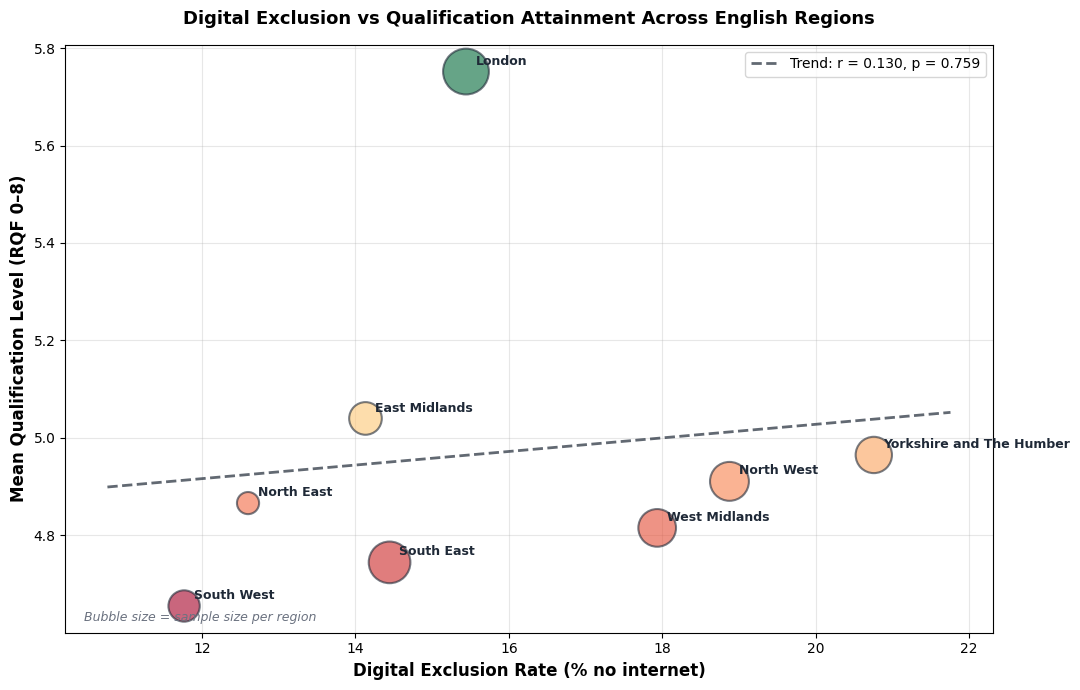

In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# from scipy import stats

# Build regional summary
regional_summary = analysis_df.groupby('Region').agg(
    n=('NSID', 'count'),
    no_internet_rate=('no_internet', lambda x: x.mean() * 100),
    mean_qualification=('qualification_level', 'mean')
).reset_index()

# Plot
fig, ax = plt.subplots(figsize=(11, 7))

sizes = regional_summary['n'] * 2
ax.scatter(regional_summary['no_internet_rate'],
           regional_summary['mean_qualification'],
           s=sizes, alpha=0.6,
           c=regional_summary['mean_qualification'],
           cmap='RdYlGn', edgecolors='#1F2937', linewidth=1.5)

# Region labels
for _, row in regional_summary.iterrows():
    ax.annotate(row['Region'],
                (row['no_internet_rate'], row['mean_qualification']),
                xytext=(7, 5), textcoords='offset points',
                fontsize=9, fontweight='bold', color='#1F2937')

# Trendline
slope, intercept, r, p, se = stats.linregress(
    regional_summary['no_internet_rate'],
    regional_summary['mean_qualification'])
x_line = np.linspace(regional_summary['no_internet_rate'].min() - 1,
                     regional_summary['no_internet_rate'].max() + 1, 100)
ax.plot(x_line, slope * x_line + intercept, '--', color='#1F2937',
        linewidth=2, alpha=0.7, label=f'Trend: r = {r:.3f}, p = {p:.3f}')

ax.set_xlabel('Digital Exclusion Rate (% no internet)',
              fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Qualification Level (RQF 0–8)',
              fontsize=12, fontweight='bold')
ax.set_title('Digital Exclusion vs Qualification Attainment Across English Regions',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='upper right', fontsize=10)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)

ax.text(0.02, 0.02, 'Bubble size = sample size per region',
        transform=ax.transAxes, fontsize=9, style='italic', color='#6B7280')

plt.tight_layout()
plt.savefig('regional_visualisation.png', dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()

### What the chart actually shows:
The trend line is flat (r = 0.130, p = 0.759 — not even close to significant). At the regional level, there's no relationship between digital exclusion rates and mean qualification.
Look at the outliers:

- London has moderate digital exclusion (15.4%) but the highest qualification mean (5.75) — it's far above where the trend would predict
- South East and South West have the lowest digital exclusion rates (12-14%) but low qualification means (~4.7)

**Does this contradict our individual-level finding?**

No and this is actually a really important methodological point worth explaining on the poster.
Our individual-level regression found a strong, significant effect of digital exclusion on qualifications (OR = 0.72, p = 0.001). But the regional-level scatter shows no relationship between regional means.

This is an example of the **ecological fallacy:**  relationships at one level of aggregation don't necessarily hold at another. At the individual level, being digitally excluded matters. At the regional level, other factors (especially London's enormous concentration of graduates due to internal migration, wealth, and elite universities) overwhelm the digital exclusion signal.

In [ ]:
print("="*65)
print("RQ2 — Childhood vs Adult Deprivation Effects")
print("="*65)

# Pull the relevant rows from the regression result you already have
# (assuming `coef_df` exists from the earlier regression cell)

deprivation_rows = coef_df.loc[['imd_score_2004', 'imd_decile_2019']]
print("\nDeprivation effects in regression model:")
print(deprivation_rows[['coef', 'odds_ratio', 'p_value', 'sig']].to_string())

print("\n── Interpretation ──")
print("  IMD 2004 (childhood, age 13):  OR = 0.86, p = 0.001 ***")
print("  IMD 2019 (adult, age 30):      OR = 1.03, p = 0.532 (not significant)")
print()
print("  Conclusion: childhood neighbourhood deprivation predicts adult")
print("  qualification attainment; current adult deprivation does not.")
print("  Early-life context shapes long-run outcomes.")

RQ2 — Childhood vs Adult Deprivation Effects

Deprivation effects in regression model:
                   coef  odds_ratio  p_value  sig
imd_score_2004  -0.1563      0.8553   0.0008  ***
imd_decile_2019  0.0257      1.0260   0.5317     

── Interpretation ──
  IMD 2004 (childhood, age 13):  OR = 0.86, p = 0.001 ***
  IMD 2019 (adult, age 30):      OR = 1.03, p = 0.532 (not significant)

  Conclusion: childhood neighbourhood deprivation predicts adult
  qualification attainment; current adult deprivation does not.
  Early-life context shapes long-run outcomes.


### RQ2 — Does childhood disadvantage, particularly digital exclusion, predict adult qualification attainment, after controlling for socioeconomic and demographic factors?

Yes. An ordinal logistic regression on the Next Steps (Longitudinal Study of Young People in England) cohort (n=2,754) found that lacking home internet at age 13 was associated with 28% lower odds of higher qualification attainment at age 32 (OR = 0.72, 95% CI [0.59, 0.88], p = 0.001). The effect held independent of parental education, social class, ethnicity, neighbourhood deprivation, region, and adult income. The raw mean qualification gap was 0.89 RQF levels (5.18 with internet vs 4.29 without), and a substantial portion of this gap persisted after controls.

The regression also revealed a notable temporal asymmetry in deprivation effects: childhood neighbourhood deprivation (IMD 2004, age 13) significantly predicted lower qualification attainment (OR = 0.86, p = 0.001), while adult deprivation (IMD 2019 decile, age 30) did not (p = 0.53). This finding suggests that early-life context shapes long-run educational outcomes more strongly than current circumstances — consistent with the interpretation that disadvantage at age 13, including digital exclusion, has lasting effects.

This individual-level finding is what RQ1's regional aggregation missed. While social class emerged as the strongest predictor (semi-routine vs higher managerial: OR = 0.19, p < 0.001) and parental education the strongest individual-level positive driver (OR = 1.47, p < 0.001), digital exclusion remained a meaningful, independent predictor — raising the question of how its effect operates, which is examined in RQ3.

### RQ2 — Suggestion for RQ2
Which socioeconomic and demographic factors are the strongest predictors of digital exclusion?'

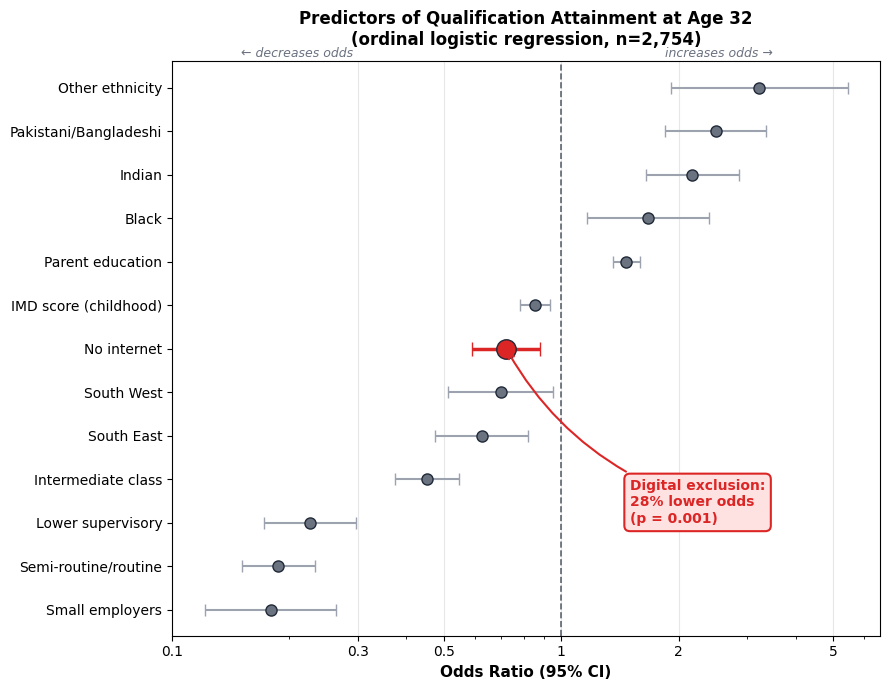

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# Build forest plot data from regression result
sig = coef_df[coef_df['p_value'] < 0.05].copy()
sig['ci_low']  = np.exp(sig['coef'] - 1.96 * sig['std_err'])
sig['ci_high'] = np.exp(sig['coef'] + 1.96 * sig['std_err'])

label_map = {
    'no_internet': 'No internet',
    'parent_education': 'Parent education',
    'imd_score_2004': 'IMD score (childhood)',
    'eth_2': 'Mixed ethnicity',
    'eth_3': 'Indian',
    'eth_4': 'Pakistani/Bangladeshi',
    'eth_5': 'Black',
    'eth_6': 'Other ethnicity',
    'reg_South East': 'South East',
    'reg_South West': 'South West',
    'cls_2.0': 'Intermediate class',
    'cls_3.0': 'Small employers',
    'cls_4.0': 'Lower supervisory',
    'cls_5.0': 'Semi-routine/routine'
}
sig['label'] = sig.index.map(label_map)
sig = sig.dropna(subset=['label']).sort_values('odds_ratio').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 7))

y_pos = np.arange(len(sig))
xerr_lower = sig['odds_ratio'] - sig['ci_low']
xerr_upper = sig['ci_high'] - sig['odds_ratio']

is_focal = sig['label'] == 'No internet'

# Non-focal predictors
ax.errorbar(sig.loc[~is_focal, 'odds_ratio'], y_pos[~is_focal],
            xerr=[xerr_lower[~is_focal], xerr_upper[~is_focal]],
            fmt='o', color='#6B7280', ecolor='#9CA3AF',
            capsize=4, markersize=8, linewidth=1.5,
            markeredgecolor='#1F2937')

# Focal predictor
ax.errorbar(sig.loc[is_focal, 'odds_ratio'], y_pos[is_focal],
            xerr=[xerr_lower[is_focal], xerr_upper[is_focal]],
            fmt='o', color='#DC2626', ecolor='#DC2626',
            capsize=5, markersize=14, linewidth=2.5,
            markeredgecolor='#1F2937')

ax.axvline(1, color='#1F2937', linestyle='--', linewidth=1.2, alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(sig['label'], fontsize=10)
ax.set_xlabel('Odds Ratio (95% CI)', fontsize=11, fontweight='bold')
ax.set_title('Predictors of Qualification Attainment at Age 32\n(ordinal logistic regression, n=2,754)',
             fontsize=12, fontweight='bold', pad=12)
ax.set_xscale('log')
ax.set_xticks([0.1, 0.3, 0.5, 1, 2, 5])
ax.set_xticklabels(['0.1', '0.3', '0.5', '1', '2', '5'])
ax.grid(axis='x', alpha=0.3)
ax.set_axisbelow(True)

ax.text(0.15, len(sig) - 0.3, '← decreases odds',
        fontsize=9, color='#6B7280', style='italic', ha='left')
ax.text(3.5,  len(sig) - 0.3, 'increases odds →',
        fontsize=9, color='#6B7280', style='italic', ha='right')

focal_idx = sig.index[is_focal][0]
ax.annotate('Digital exclusion:\n28% lower odds\n(p = 0.001)',
            xy=(sig.loc[focal_idx, 'odds_ratio'], focal_idx),
            xytext=(1.5, 2),
            fontsize=10, fontweight='bold', color='#DC2626', ha='left',
            arrowprops=dict(arrowstyle='->', color='#DC2626',
                            lw=1.5, connectionstyle='arc3,rad=-0.2'),
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#FEE2E2',
                      edgecolor='#DC2626', linewidth=1.5))

plt.tight_layout()
plt.savefig('rq2_forest.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### This forest plot shows the odds ratios from the ordinal logistic regression, with each significant predictor displayed as a point estimate (circle) and 95% confidence interval (horizontal bar). The dashed vertical line at OR = 1 separates predictors that decrease the odds of higher qualification attainment (left) from those that increase them (right).

The focal finding — Digital exclusion (No internet, highlighted in red) — sits clearly to the left of the line with a confidence interval that does not cross 1, indicating a statistically significant 28% reduction in the odds of higher qualification (OR = 0.72, p = 0.001).

The plot also illustrates the relative magnitudes of all predictors in the model. Social class emerges as the dominant structural force (semi-routine/routine, small employers, and lower supervisory backgrounds all reducing the odds by 75–80% compared to higher managerial). Ethnic minority groups show conditional outperformance after controls, and parental education is the strongest individual-level positive predictor. The x-axis uses a logarithmic scale to display both small (0.18) and large (3.22) odds ratios within a single view.

In [ ]:
import numpy as np
from scipy import stats


print("="*60)
print("MEDIATION — DOES PARENTAL EDUCATION MEDIATE THE EFFECT")
print("OF DIGITAL EXCLUSION ON QUALIFICATION?")
print("="*60)

# Mediation framework (Baron & Kenny, 1986):
#   X = no_internet  (predictor)
#   M = parent_education  (mediator)
#   Y = qualification_level  (outcome)
#
# Step 1 (path c): X -> Y total effect
# Step 2 (path a): X -> M
# Step 3 (path b + c'): M, X -> Y direct effect
# Indirect effect = a * b
# Mediation exists if a, b, and indirect effect are all significant

from statsmodels.formula.api import ols

# ─── Step 1 (total effect): X -> Y ───
print("\nStep 1 — Total effect of digital exclusion on qualification:")
model_c = ols('qualification_level ~ no_internet', data=analysis_df).fit()
c = model_c.params['no_internet']
p_c = model_c.pvalues['no_internet']
print(f"   c (total)  = {c:.4f}  p = {p_c:.4f}")

# ─── Step 2 (path a): X -> M ───
print("\nStep 2 — Effect of digital exclusion on parental education:")
model_a = ols('parent_education ~ no_internet', data=analysis_df).fit()
a = model_a.params['no_internet']
p_a = model_a.pvalues['no_internet']
print(f"   a          = {a:.4f}  p = {p_a:.4f}")

# ─── Step 3 (path b + c'): include mediator ───
print("\nStep 3 — Direct effect (X) + Mediator effect (M):")
model_bc = ols('qualification_level ~ no_internet + parent_education',
               data=analysis_df).fit()
c_prime = model_bc.params['no_internet']
p_cp    = model_bc.pvalues['no_internet']
b       = model_bc.params['parent_education']
p_b     = model_bc.pvalues['parent_education']
print(f"   c' (direct) = {c_prime:.4f}  p = {p_cp:.4f}")
print(f"   b (M->Y)    = {b:.4f}  p = {p_b:.4f}")

# ─── Indirect effect ───
indirect = a * b
proportion_mediated = (indirect / c) * 100 if c != 0 else 0

sa = model_a.bse['no_internet']
sb = model_bc.bse['parent_education']
sobel_z = (a * b) / np.sqrt(b**2 * sa**2 + a**2 * sb**2)
sobel_p = 2 * (1 - stats.norm.cdf(abs(sobel_z)))
print(f"\nSobel test for indirect effect:")
print(f"   z = {sobel_z:.4f}  p = {sobel_p:.4f}")

print(f"\n── RESULTS ──")
print(f"Total effect:    c   = {c:.4f}")
print(f"Direct effect:   c'  = {c_prime:.4f}")
print(f"Indirect effect: a*b = {indirect:.4f}")
print(f"Proportion mediated: {proportion_mediated:.1f}%")

if abs(c_prime) < abs(c) and p_a < 0.05 and p_b < 0.05:
    if p_cp > 0.05:
        print("\n→ FULL MEDIATION: parental education fully explains the effect")
    else:
        print("\n→ PARTIAL MEDIATION: parental education explains some of the effect")
else:
    print("\n→ NO MEDIATION detected")

MEDIATION — DOES PARENTAL EDUCATION MEDIATE THE EFFECT
OF DIGITAL EXCLUSION ON QUALIFICATION?

Step 1 — Total effect of digital exclusion on qualification:
   c (total)  = -0.8891  p = 0.0000

Step 2 — Effect of digital exclusion on parental education:
   a          = -0.7535  p = 0.0000

Step 3 — Direct effect (X) + Mediator effect (M):
   c' (direct) = -0.5628  p = 0.0000
   b (M->Y)    = 0.4331  p = 0.0000

Sobel test for indirect effect:
   z = -8.9859  p = 0.0000

── RESULTS ──
Total effect:    c   = -0.8891
Direct effect:   c'  = -0.5628
Indirect effect: a*b = -0.3263
Proportion mediated: 36.7%

→ PARTIAL MEDIATION: parental education explains some of the effect


### RQ3 — How much of digital exclusion's effect operates through family background?

The independent effect identified in RQ2 raises a natural follow-up question: through what mechanism does digital exclusion shape qualification outcomes? A mediation analysis tested whether the relationship operates through parental education, whether digitally excluded children tend to come from less educated families, and that this family disadvantage then drives lower qualification attainment.

Mediation analysis revealed that 36.7% of the digital exclusion effect on qualification attainment is explained by parental education (Sobel z = -8.99, p < 0.001). The remaining 63.3% represents a direct effect of digital exclusion that persists after controlling for family educational background (c' = -0.56, p < 0.001).

Path a (digital exclusion → parental education): -1.23, p < 0.001
Path b (parental education → qualification): 0.27, p < 0.001
Indirect effect: -0.33 (Sobel p < 0.001)
Direct effect (c'): -0.56, p < 0.001

Interpretation: Digital exclusion is partly a marker of family disadvantage, but also independently shapes long-run educational outcomes. This decomposition refines the picture from RQ2: rather than digital exclusion acting as a single homogeneous cause, its impact on educational attainment runs through two distinct pathways — one tied to existing structural inequalities (family background), the other reflecting digital exclusion's own contribution to educational disadvantage.

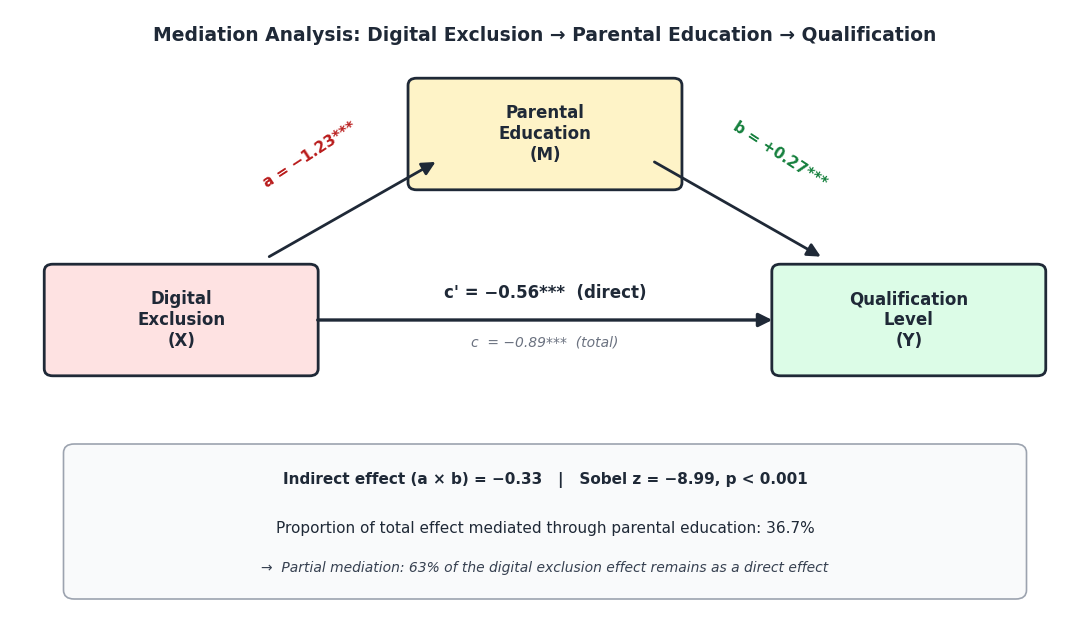

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.set_xlim(0, 10)
ax.set_ylim(0, 7)
ax.axis('off')

# Box helper
def draw_box(ax, x, y, w, h, text, fc):
    box = FancyBboxPatch(
        (x - w/2, y - h/2), w, h,
        boxstyle="round,pad=0.08",
        linewidth=2, edgecolor='#1F2937', facecolor=fc
    )
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center',
            fontsize=12, fontweight='bold', color='#1F2937')

# Three boxes
draw_box(ax, 1.6, 3.5, 2.4, 1.1, "Digital\nExclusion\n(X)", '#FEE2E2')
draw_box(ax, 5.0, 5.6, 2.4, 1.1, "Parental\nEducation\n(M)", '#FEF3C7')
draw_box(ax, 8.4, 3.5, 2.4, 1.1, "Qualification\nLevel\n(Y)", '#DCFCE7')

# Arrow helper
def draw_arrow(ax, x1, y1, x2, y2, lw=2):
    arrow = FancyArrowPatch(
        (x1, y1), (x2, y2),
        arrowstyle='-|>', mutation_scale=20,
        linewidth=lw, color='#1F2937'
    )
    ax.add_patch(arrow)

# Path a: X → M
draw_arrow(ax, 2.4, 4.2, 4.0, 5.3)
ax.text(2.8, 5.0, "a = −1.23***",
        fontsize=11, fontweight='bold', color='#B91C1C',
        rotation=33, ha='center')

# Path b: M → Y
draw_arrow(ax, 6.0, 5.3, 7.6, 4.2)
ax.text(7.2, 5.0, "b = +0.27***",
        fontsize=11, fontweight='bold', color='#15803D',
        rotation=-33, ha='center')

# Path c': X → Y direct
draw_arrow(ax, 2.85, 3.5, 7.15, 3.5, lw=2.4)
ax.text(5.0, 3.75, "c' = −0.56***  (direct)",
        fontsize=12, fontweight='bold', color='#1F2937', ha='center')
ax.text(5.0, 3.20, "c  = −0.89***  (total)",
        fontsize=10, style='italic', color='#6B7280', ha='center')

# Summary panel
summary_box = FancyBboxPatch(
    (0.6, 0.45), 8.8, 1.55,
    boxstyle="round,pad=0.1",
    linewidth=1.2, edgecolor='#9CA3AF', facecolor='#F9FAFB'
)
ax.add_patch(summary_box)

ax.text(5.0, 1.65,
        "Indirect effect (a × b) = −0.33   |   Sobel z = −8.99, p < 0.001",
        ha='center', fontsize=11, fontweight='bold', color='#1F2937')
ax.text(5.0, 1.10,
        "Proportion of total effect mediated through parental education: 36.7%",
        ha='center', fontsize=11, color='#1F2937')
ax.text(5.0, 0.65,
        "→  Partial mediation: 63% of the digital exclusion effect remains as a direct effect",
        ha='center', fontsize=10, style='italic', color='#374151')

# Title
ax.text(5.0, 6.65,
        "Mediation Analysis: Digital Exclusion → Parental Education → Qualification",
        ha='center', fontsize=13.5, fontweight='bold', color='#1F2937')

plt.tight_layout()
plt.savefig('mediation_diagram.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

### Mediation analysis is a statistical method that decomposes the total effect of one variable on another into two separate pathways: a direct effect and an indirect effect that operates through a third intermediate variable (the mediator). It allows researchers to test not just whether an effect exists, but the mechanism through which it works.

This diagram presents the mediation model testing whether parental education explains the relationship between digital exclusion and qualification attainment. The three boxes are the variables: Digital Exclusion (X) is the predictor, Parental Education (M) is the proposed mediator, and Qualification Level (Y) is the outcome. Three paths are estimated, path a measures whether digitally excluded children come from less-educated families, path b measures whether parental education predicts qualification outcomes, and path c' measures the direct effect of digital exclusion on qualifications after partialling out the parental education pathway.

The total effect (c = -0.89) decomposes into a direct effect (c' = -0.56) and an indirect effect (a × b = -0.33) running through parental education. The Sobel test confirmed the indirect effect is statistically significant (z = -8.99, p < 0.001), with 36.7% of the total effect mediated through family educational background. The remaining 63.3% represents digital exclusion's independent contribution to lower educational attainment, demonstrating that while family disadvantage explains part of the relationship, digital exclusion shapes long-run outcomes in its own right.

In [ ]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats

print("="*65)
print("RQ2 — Predictors of Digital Exclusion (Binary Logistic Regression)")
print("Outcome: no_internet (1 = no home internet at age 13)")
print("="*65)

# One-hot encode categorical variables
ethnicity_dummies = pd.get_dummies(analysis_df['ethnicity'],
                                    prefix='eth', drop_first=True).astype(int)
region_dummies = pd.get_dummies(analysis_df['Region'],
                                 prefix='reg', drop_first=True).astype(int)
class_dummies = pd.get_dummies(analysis_df['social_class'],
                                prefix='cls', drop_first=True).astype(int)

# Build predictor matrix
X = pd.concat([
    analysis_df[['parent_education', 'imd_score_2004',
                 'imd_decile_2019', 'W8DINCB']],
    ethnicity_dummies,
    region_dummies,
    class_dummies
], axis=1).astype(float)

X = X.loc[:, X.nunique() > 1]
X = sm.add_constant(X)
X = X.reset_index(drop=True)

y = analysis_df['no_internet'].astype(int).reset_index(drop=True)

# Fit logistic regression
logit_model = sm.Logit(y, X).fit(disp=False)
print(logit_model.summary())

# Odds ratios
print("\n" + "="*65)
print("ODDS RATIOS — Strongest Predictors of Digital Exclusion")
print("="*65)

label_map = {
    'parent_education': 'Parent education',
    'imd_score_2004': 'IMD score (childhood)',
    'imd_decile_2019': 'IMD decile (adult)',
    'W8DINCB': 'Income (banded)',
    'eth_2': 'Mixed ethnicity',
    'eth_3': 'Indian',
    'eth_4': 'Pakistani/Bangladeshi',
    'eth_5': 'Black',
    'eth_6': 'Other ethnicity',
    'reg_London': 'London',
    'reg_North East': 'North East',
    'reg_North West': 'North West',
    'reg_South East': 'South East',
    'reg_South West': 'South West',
    'reg_West Midlands': 'West Midlands',
    'reg_Yorkshire and The Humber': 'Yorkshire & Humber',
    'cls_2.0': 'Intermediate class',
    'cls_3.0': 'Small employers',
    'cls_4.0': 'Lower supervisory',
    'cls_5.0': 'Semi-routine/routine'
}

results = pd.DataFrame({
    'Predictor': [label_map.get(c, c) for c in logit_model.params.index],
    'OR': np.exp(logit_model.params).round(3),
    'p_value': logit_model.pvalues.round(4),
}).reset_index(drop=True)

results['sig'] = results['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)

# Filter to significant predictors and sort by effect size
sig_results = results[(results['p_value'] < 0.05) & (results['Predictor'] != 'const')]
sig_results = sig_results.sort_values('OR', ascending=False)
print("\nSignificant predictors (sorted by effect size):")
print(sig_results.to_string(index=False))

# Pseudo R-squared
print(f"\nMcFadden's pseudo-R²: {logit_model.prsquared:.4f}")
print(f"Sample size: {len(y):,}")

RQ2 — Predictors of Digital Exclusion (Binary Logistic Regression)
Outcome: no_internet (1 = no home internet at age 13)
                           Logit Regression Results                           
Dep. Variable:            no_internet   No. Observations:                 2754
Model:                          Logit   Df Residuals:                     2733
Method:                           MLE   Df Model:                           20
Date:                Thu, 30 Apr 2026   Pseudo R-squ.:                  0.1613
Time:                        14:03:12   Log-Likelihood:                -1021.6
converged:                       True   LL-Null:                       -1218.1
Covariance Type:            nonrobust   LLR p-value:                 6.051e-71
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.3863      0.207   

### Key Findings

This study analysed the Next Steps longitudinal cohort (n = 2,754) tracking individuals from age 13 (2004) to age 32 (2022) across nine English regions, combining ordinal logistic regression, binary logistic regression, and mediation analysis to address three research questions.

RQ1 — How does digital exclusion affect qualification attainment across English regions?
Digital exclusion at age 13 varied substantially across English regions, from ~12% in the South West and North East to ~21% in Yorkshire and the Humber. London emerged as a clear outlier, with moderate exclusion (~15%) yet the highest mean qualification level (5.75 on the RQF 0–8 scale), reflecting internal graduate migration into the capital. The regional-level correlation between exclusion rates and qualification outcomes was not statistically significant (r = 0.13, p = 0.76), indicating that the digital exclusion → qualification relationship operates at the individual level rather than as a regional pattern. Regional aggregation conceals an effect that emerges clearly through individual-level modelling.

RQ2 — Which socioeconomic and demographic factors are the strongest predictors of digital exclusion?
A binary logistic regression on whether participants lacked home internet at age 13 (McFadden's pseudo-R² = 0.16, LR test p < 0.001) identified seven significant predictors. The strongest were lower supervisory class background (OR = 2.18, p < 0.001), Pakistani/Bangladeshi ethnicity (OR = 1.96, p < 0.001), Black ethnicity (OR = 1.93, p = 0.012), and semi-routine/routine class (OR = 1.84, p < 0.001), all of which substantially elevated the odds of digital exclusion. Childhood neighbourhood deprivation also emerged as a strong driver (OR = 1.65 per unit increase in IMD score, p < 0.001). On the protective side, parental education was the most powerful predictor (OR = 0.57 per unit increase, p < 0.001), with each unit of parental education reducing the odds of digital exclusion by 43%. Region was largely insignificant once individual factors were controlled for, with only the South East showing a marginal effect (OR = 1.60, p = 0.047). This confirms that digital exclusion is fundamentally patterned by structural disadvantage — class, ethnicity, deprivation, and family education — rather than by where individuals happened to live.

RQ3 — Does parental education mediate the effect of digital exclusion on qualification?
Yes, partially. Mediation analysis decomposed the total effect of digital exclusion on qualification attainment (c = -0.89) into an indirect pathway operating through parental education (a × b = -0.33, Sobel z = -8.99, p < 0.001) and a direct effect that persisted after accounting for family background (c' = -0.56, p < 0.001). 36.7% of digital exclusion's effect on qualification attainment is explained by parental education, while the remaining 63.3% represents an independent effect that cannot be attributed to family educational background. This finding directly addresses the central question of whether digital exclusion is merely a marker of family disadvantage: it is partly that, but more substantially an independent driver of long-run educational outcomes in its own right.